<a href="https://colab.research.google.com/github/Nipun1a/Linear_regression/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linear Regression**

Y=wX + b

Y --> Dependent Variable
X --> Independent Variable
w --> weight
b --> bias

Gradient Descent:

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for
updating the parameters of the learning model.

w=w -a*dw

b = b - a*db

Learning Rate:

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum
of a loss function.

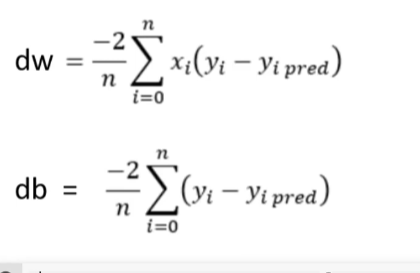

Linear Regression


In [40]:
import numpy as np

In [41]:
class Linear_Regression():
# initiating the parameters (learning rate & no. of iterations)
 def __init__(self,learning_rate, no_of_iterations ):

  self.learning_rate = learning_rate
  self.no_of_iterations = no_of_iterations

 def fit(self, X,Y):
  #number of training ex & number of features

  self.m, self.n = X.shape #no. of rows & columns
  #initiating weight & bias value
  self.w = np.zeros(self.n)
  self.b = 0
  self.X = X
  self.Y = Y

  #implementinf Gradient Descent

  for i in range(self.no_of_iterations):
   self.update_weights()

 def update_weights(self, ):
  Y_prediction = self.predict(self.X)

  #calculate gradients

  dw = - (2 * (self.X.T).dot(self.Y - Y_prediction)) / self.m
  db = - (2 * np.sum(self.Y - Y_prediction)) / self.m

  #updating the weights

  self.w = self.w - self.learning_rate * dw
  self.b = self.b - self.learning_rate * db

# Line function for prediction
 def predict(self, X ):

  return X.dot(self.w) + self.b



y = 0(x) +0

Work flow of the Linear Regression model:

Step 1: Set learning Rate & Number of Iterations; Initiate Random weight and bias value.

Step 2: Build Linear Regression Equation. (y = wx + b)

Step 3: Find the "y pred" value for given x value for the corresponding weight & bias.

Step 4: Check the loss function for these parameter values. ( difference between "y pred" & "true y")

Step 5: Update the parameter values using Gradient Descent. (new weight & bias value)

Step 6: Step 3, 4, 5 are repeated till we get minimum loss function

Finally we will get the best model (best weight and bias value) as it has minimum loss function.

**Using Linear Regression model for Prediction**

In [42]:
# importing the dependencies
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


Data Pre-Processing

In [43]:
#loadin the data from csv file to a pandas dataframe

salary_data = pd.read_csv('/content/salary_data.csv')

In [44]:
# printing the first 5 columns of the dataframe
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [45]:
#last 5 rows of the dataset
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [46]:
# number of rows & columns in the dataframe
salary_data.shape

(30, 2)

In [47]:
#checking for missing values
salary_data.isnull().sum()

,0
YearsExperience,0
Salary,0


Splitting the feature and the target

In [48]:
X = salary_data.iloc[:,:-1].values
Y = salary_data.iloc[:,1].values

In [49]:
print(X)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [50]:
print(Y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


Splitting the dataset into training & test data

In [51]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.33, random_state = 2)

Training the Linear Regression Model

In [52]:
model = Linear_Regression(learning_rate=0.02, no_of_iterations=1000)

In [53]:
model.fit(X_train, Y_train)

In [54]:
# printing the parameter values (weights & bias)

print('weight =', model.w[0])
print('bias =', model.b)

weight = 9514.400999035135
bias = 23697.406507136307


y = 9514(x) + 23697

salary = 9514(experience) + 23697

predict the salary value for the test data

In [55]:
test_data_prediction = model.predict(X_test)

In [56]:
print(test_data_prediction)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


Visualizing the predicted values & actual Values

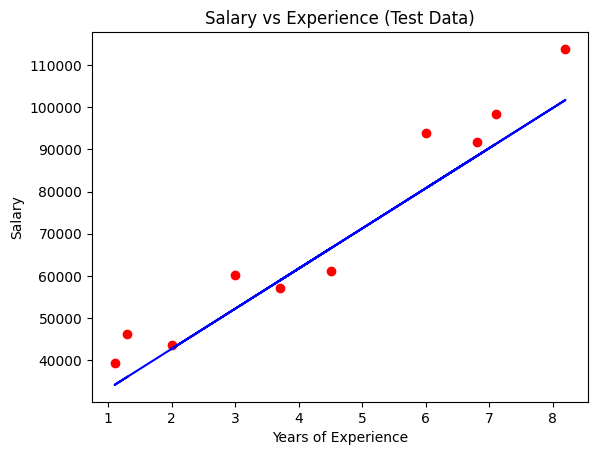

In [57]:
plt.scatter(X_test, Y_test, color = 'red')
plt.plot(X_test, test_data_prediction, color = 'blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience (Test Data)')
plt.show()